In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Метод дихотомии

In [24]:
def dichotomy_method(func, a, b, eps=10^-4):
    x = (a + b) / 2

    if b - a > 2 * eps:
        x_1 = x - eps / 2
        x_2 = x + eps / 2
        f_x_1 = func(x_1)
        f_x_2 = func(x_2)

        if f_x_1 > f_x_2:
            return dichotomy_method(func, x_1, b, eps)
        else:
            return dichotomy_method(func, a, x_2, eps)
    else:
        return x

# Метод Фибоначчи

In [25]:
def fibonacci_method(func, a, b, eps):
    L = b - a
    fib = [1, 1]

    while fib[-1] < L / eps:
        fib.append(fib[-1] + fib[-2])
    n = len(fib)

    x_1 = a + (fib[n - 2] / fib[n - 1]) * L
    x_2 = b - (fib[n - 2] / fib[n - 1]) * L
    f_x_1 = func(x_1)
    f_x_2 = func(x_2)

    while n > 2:
        if f_x_1 > f_x_2:
            b = x_1
            x_1 = x_2
            f_x_1 = f_x_2
            L = b - a
            n -= 1
            x_2 = b - (fib[n - 2] / fib[n - 1]) * L
            f_x_2 = func(x_2)
        else:
            a = x_2
            x_2 = x_1
            f_x_2 = f_x_1
            L = b - a
            n -= 1
            x_1 = a + (fib[n - 2] / fib[n - 1]) * L
            f_x_1 = func(x_1)

    return x_1 if f_x_1 < f_x_2 else x_2

# Метод золотого сечения

In [26]:
def golden_section_method(func, a, b, eps):
    L = b - a
    x_1 = a + L * 0.618
    x_2 = b - L * 0.618
    f_x_1 = func(x_1)
    f_x_2 = func(x_2)

    while L > eps:
        if f_x_1 > f_x_2:
            b = x_1
            f_x_1 = f_x_2
            x_1 = x_2
            L = b - a
            x_2 = a + (b - x_1)
            f_x_2 = func(x_2)
        else:
            a = x_2
            f_x_2 = f_x_1
            x_2 = x_1
            L = b - a
            x_1 = b - (x_2 - a)
            f_x_1 = func(x_1)
    
    return x_1 if f_x_1 < f_x_2 else x_2

# Проверка алгоритмов

In [27]:
f = lambda x: np.cos(x)
print(dichotomy_method(f, 0, np.pi, 0.00001))
print(fibonacci_method(f, 0, np.pi, 0.00001))
print(golden_section_method(f, 0, np.pi, 0.00001))
f = lambda x: np.pow(x, 4) - x
print(dichotomy_method(f, 0, 1, 0.00001))
print(fibonacci_method(f, 0, 1, 0.00001))
print(golden_section_method(f, 0, 1, 0.00001))

3.1415846575431035
3.141592653589793
3.1353094682826104
0.6299616215133667
0.6299621889235788
0.6299999999999998


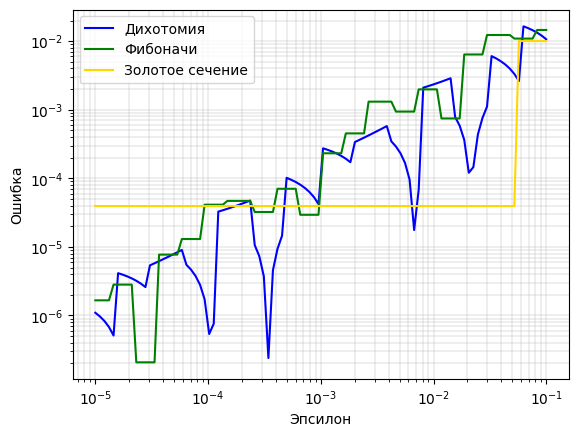

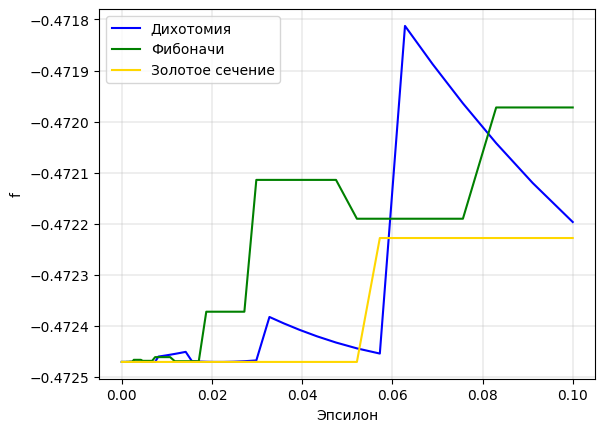

In [28]:
eps_values = np.logspace(-5, -1, 100)
errors_dih = []
errors_fib = []
errors_gol = []
f_dih = []
f_fib = []
f_gol = []

for eps in eps_values:
    errors_dih.append(abs(dichotomy_method(f, 0, 1, eps) - (1 / 4) ** (1 / 3)))
    errors_fib.append(abs(fibonacci_method(f, 0, 1, eps) - (1 / 4) ** (1 / 3)))
    errors_gol.append(abs(golden_section_method(f, 0, 1, eps) - (1 / 4) ** (1 / 3)))
    f_dih.append(f(dichotomy_method(f, 0, 1, eps)))
    f_fib.append(f(fibonacci_method(f, 0, 1, eps)))
    f_gol.append(f(golden_section_method(f, 0, 1, eps)))

plt.plot(eps_values, errors_dih, color='blue', label="Дихотомия")
plt.plot(eps_values, errors_fib, color='green', label="Фибоначи")
plt.plot(eps_values, errors_gol, color='gold', label="Золотое сечение")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Эпсилон")
plt.ylabel("Ошибка")
plt.grid(True, which="both", linewidth=0.3)
plt.legend()
plt.show()

plt.plot(eps_values, f_dih, color='blue', label="Дихотомия")
plt.plot(eps_values, f_fib, color='green', label="Фибоначи")
plt.plot(eps_values, f_gol, color='gold', label="Золотое сечение")
plt.xlabel("Эпсилон")
plt.ylabel("f")
plt.grid(True, which="both", linewidth=0.3)
plt.legend()
plt.show()